## Setup

In [1]:
%load_ext autoreload
%autoreload 2

Set up the working environment:

In [2]:
# To ensure reproducibility
seed = 7214

# Load basic libraries
import os
import sys
from pathlib import Path
from scipy.stats import uniform, randint, loguniform

# Add the project's root directory to sys.path to ensure we can import from src/
root_path = Path(os.getcwd()).resolve().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

# Import the config module to access paths and settings
from src.config import *

# Use predefined paths from config
file_path = get_data_path("clinical_data_no_nutrition.parquet")
results_path = get_results_path("no_nutrition_data")

print(f"Project's root: {root_path}")
print(f"Loading data from: {file_path}")
print(f"Saving results to: {results_path}")

Project's root: /workspaces/TFM
Loading data from: /workspaces/TFM/data/clean/clinical_data_no_nutrition.parquet
Saving results to: /workspaces/TFM/results/models/no_nutrition_data


Load libraries:

In [3]:
# DATA WRANGLING AND STATISTICS
import pandas as pd
import numpy as np

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold

# HYPERPARAMETER TUNING
from optuna.distributions import IntDistribution, FloatDistribution, CategoricalDistribution

# MODEL TRAINING 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

# MODEL EVALUATION
from sklearn.metrics import accuracy_score, precision_score, recall_score, make_scorer

# CUSTOM MODULES
from src.models import *


## Data

Load the data and check the structure: and split the data into target class and features:

In [4]:
# Load data
df = pd.read_parquet(file_path)

# Check general structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   sex                   720 non-null    category
 1   age                   720 non-null    float64 
 2   smoking_status        720 non-null    category
 3   code                  720 non-null    float64 
 4   center                720 non-null    category
 5   intervention          720 non-null    category
 6   BMI                   720 non-null    float64 
 7   Met                   720 non-null    float64 
 8   glucose               690 non-null    float64 
 9   type1_diabetes        720 non-null    category
 10  type2_diabetes        720 non-null    category
 11  HDL                   646 non-null    float64 
 12  triglicerides         650 non-null    float64 
 13  hypercholesterolemia  720 non-null    category
 14  OSA                   720 non-null    category
 15  renal_insuf      

Separate the features from the target class:

In [5]:
# Drop the target class and the non-informative features
X = df.drop(["AF_recurrence", "code", "center"], axis=1)

# Select the target class and encode it manually
y = df["AF_recurrence"].map({"no":0, "yes":1})

Divide data set into train and test set:

In [6]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y,
    )

# Compute the predicted class ratio
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()

ratio = negatives / positives

print(f"Negative cases: {negatives}, Positive cases: {positives}")
print(f"Imbalance ratio suggested: {ratio:.2f}")

Negative cases: 367, Positive cases: 209
Imbalance ratio suggested: 1.76


## Training and optimization

Training each model with stratified 5-fold cross validation:

In [7]:
# Number of splits
n = 5

# Cross-validation strategy
my_cv = StratifiedKFold(n_splits=n, shuffle=True, random_state=42)

Define metrics to evaluate:

In [8]:
# Define new metric
specificity_score = make_scorer(recall_score, pos_label=0)

# zero_division=0 to avoid errors when there are no negative samples in a fold
specificity_score._kwargs['zero_division'] = 0

# Set up the scoring dictionary for cross-validation
scoring_dict = {
        'Accuracy': 'accuracy',
        'Precision': 'precision',
        'Recall': 'recall',
        'Specificity': specificity_score,
        'ROC-AUC': 'roc_auc',
        'PR-AUC': 'average_precision'
    }

objective_metric = "PR-AUC"

#### Logistic Regression (Elastic Net)

Define the parameter distributions and set up the pipeline:

In [9]:
# Hyperparameters search space
params_EN = {
    'clf__l1_ratio': FloatDistribution(0, 1),
    'clf__C': FloatDistribution(1e-4, 1e3, log=True)
    }

# Get the preprocessor
preprocessor_EN = get_full_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_EN = Pipeline(steps=[
    ('preprocessor', preprocessor_EN),
    ('clf', LogisticRegression(random_state=seed, solver='saga', max_iter=10000))
])

Train and optimize the model:

In [10]:
(
optimized_EN, 
cv_results_EN,
fpr_EN, tpr_EN,
precs_EN, recs_EN,
study_EN
) = optimize_model_optuna_search(
    pipeline=pipe_EN, 
    param_distributions=params_EN, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    aim=scoring_dict[objective_metric],
    cv=my_cv, 
    seed=seed
    )

Starting hyperparameter optimization...
Evaluating on the training set...
Evaluating on the test set...


Check the optimization history:

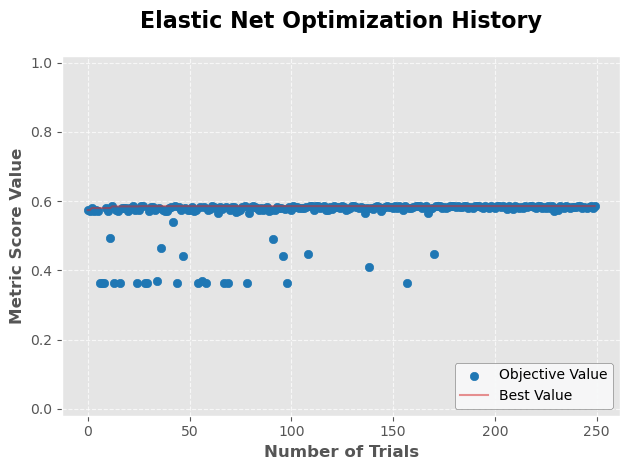

In [11]:
# Update the model's name in the study's user attributes
study_EN.set_user_attr("model_name", "Elastic Net")

# Plot the optimization history progress
plot_optimization_history(study=study_EN, output_dir=results_path, identifier="EN")

Save the optimized model and check the hyperparameters:

In [12]:
save_model(fitted_pipeline=optimized_EN, output_dir=results_path, identifier="EN")

,Hyperparameter,Optimal Value
1,C,0.111875
2,dual,False
3,fit_intercept,True
4,intercept_scaling,1
5,l1_ratio,0.902747
6,max_iter,10000
7,penalty,deprecated
8,random_state,7214
9,solver,saga
10,tol,0.0001


Check the overfitting:

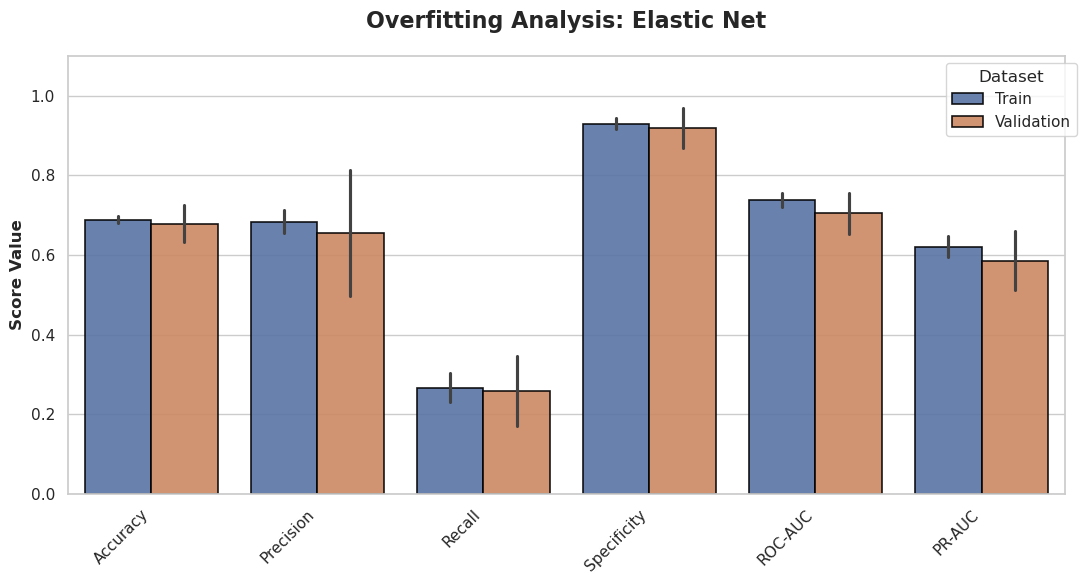

In [13]:
plot_overfitting_bars(df_cv_results=cv_results_EN, 
                    title="Elastic Net", 
                    output_dir=results_path, 
                    identifier="EN")

Take a look at the relevant columns:

In [14]:
relevant_cols, irrelevant_cols = get_relevant_features(optimized_EN)

print("relevant features: ", relevant_cols)
print("\n")
print("irrelevant features: ", irrelevant_cols)

relevant features:  ['ERAF', 'AF_type', 'AF_ablation_time', 'stroke', 'sex', 'previous_ablation', 'hypertension', 'intervention', 'Met', 'age', 'cardiomyopathy', 'OSA', 'antirrythmic_meds']


irrelevant features:  ['BMI', 'glucose', 'HDL', 'triglicerides', 'smoking_status', 'type1_diabetes', 'type2_diabetes', 'hypercholesterolemia', 'renal_insuf', 'COPD', 'LA_enlargment', 'LVEF']


Exclude irrelevant features for the rest of the models:

In [15]:
# X_train.drop(columns=irrelevant_cols, inplace=True)
# X_test.drop(columns=irrelevant_cols, inplace=True)

#### Support Vector Machine

Define the parameter distributions and set up the pipeline:

In [16]:
# Hyperparameters search space
params_dist_SVM = {
    'clf__C': FloatDistribution(1e-5, 1e3, log=True),
    'clf__kernel': CategoricalDistribution(['linear', 'rbf']),
    'clf__gamma': CategoricalDistribution(['scale', 'auto']),
    'clf__degree': IntDistribution(2, 3),
    'clf__class_weight': CategoricalDistribution([None, 'balanced'])
}

# Get preprocessor
preprocessor_SVM = get_full_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor_SVM),
    ('clf', SVC(random_state=seed, max_iter=10000))
])

Train and optimize the model:

In [17]:
(
optimized_SVM, 
cv_results_SVM,
fpr_SVM, tpr_SVM,
precs_SVM, recs_SVM,
study_SVM
) = optimize_model_optuna_search(
    pipeline=pipe_SVM, 
    param_distributions=params_dist_SVM, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    seed=seed
    )

Starting hyperparameter optimization...


/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: S

Evaluating on the training set...


/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/tfm/lib/python3.11

Evaluating on the test set...


/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Check the optimization history:

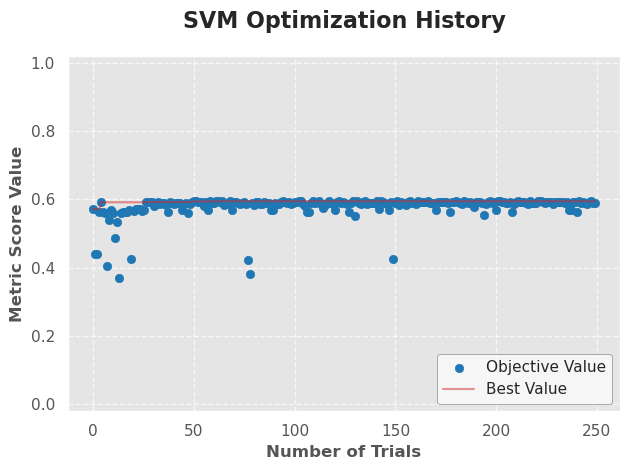

In [18]:
# Update the model's name in the study's user attributes
study_SVM.set_user_attr("model_name", "SVM")

# Plot the optimization history progress
plot_optimization_history(study=study_SVM, output_dir=results_path, identifier="SVM")

Save the optimized model and check the hyperparameters:

In [19]:
save_model(fitted_pipeline=optimized_SVM, output_dir=results_path, identifier="SVM")

,Hyperparameter,Optimal Value
1,C,0.000135
2,break_ties,False
3,cache_size,200
4,coef0,0.0
5,decision_function_shape,ovr
6,degree,2
7,gamma,auto
8,kernel,linear
9,max_iter,10000
10,probability,False


Check the overfitting:

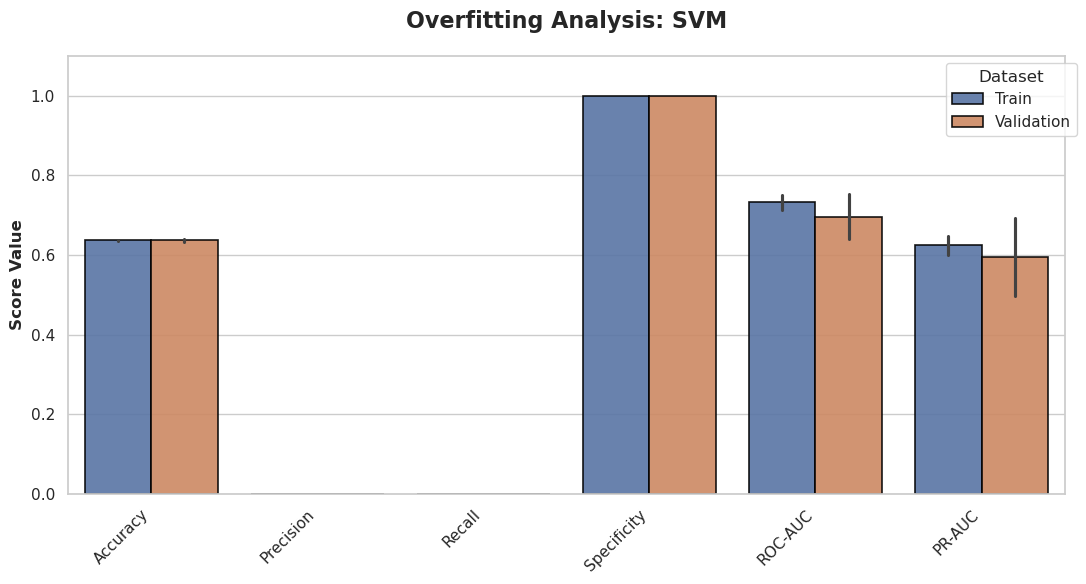

In [20]:
plot_overfitting_bars(df_cv_results=cv_results_SVM, 
                    title="SVM", 
                    output_dir=results_path, 
                    identifier="SVM")

#### Random Forest

Define the parameter distributions and set up the pipeline:

In [21]:
# Hyperparameters search space
params_dist_RF = {
    'clf__n_estimators': IntDistribution(20, 300),
    'clf__max_depth': IntDistribution(2, 32),
    'clf__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'clf__min_samples_split': IntDistribution(2, 20),
    'clf__criterion': CategoricalDistribution(['gini', 'entropy']),
    'clf__class_weight': CategoricalDistribution([None, 'balanced', 'balanced_subsample'])
}

# Get the preprocessor
preprocessor_RF = get_trees_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor_RF),
    ('clf', RandomForestClassifier(random_state=seed))
])

Train and optimize the model:

In [22]:
(
optimized_RF, 
cv_results_RF,
fpr_RF, tpr_RF,
precs_RF, recs_RF,
study_RF
) = optimize_model_optuna_search(
    pipeline=pipe_RF, 
    param_distributions=params_dist_RF, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    seed=seed
    )

Starting hyperparameter optimization...
Evaluating on the training set...
Evaluating on the test set...


Check the optimization history:

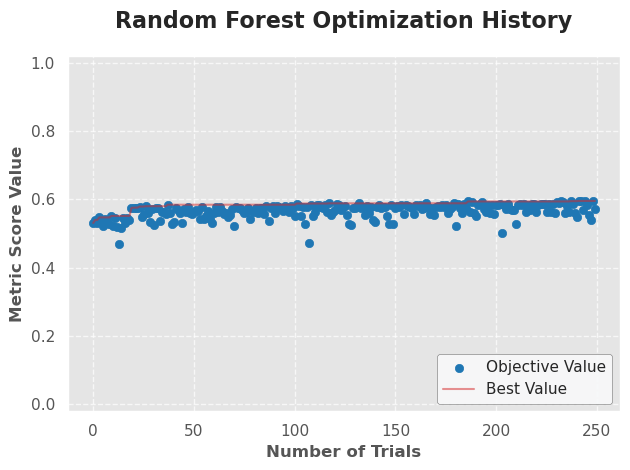

In [23]:
# Update the model's name in the study's user attributes
study_RF.set_user_attr("model_name", "Random Forest")

# Plot the optimization history progress
plot_optimization_history(study=study_RF, output_dir=results_path, identifier="RF")

Save the optimized model and check the hyperparameters:

In [24]:
save_model(fitted_pipeline=optimized_RF, output_dir=results_path, identifier="RF")

,Hyperparameter,Optimal Value
1,bootstrap,True
2,ccp_alpha,0.0
3,criterion,entropy
4,max_depth,2
5,max_features,sqrt
6,min_impurity_decrease,0.0
7,min_samples_leaf,1
8,min_samples_split,11
9,min_weight_fraction_leaf,0.0
10,n_estimators,27


Check the overfitting:

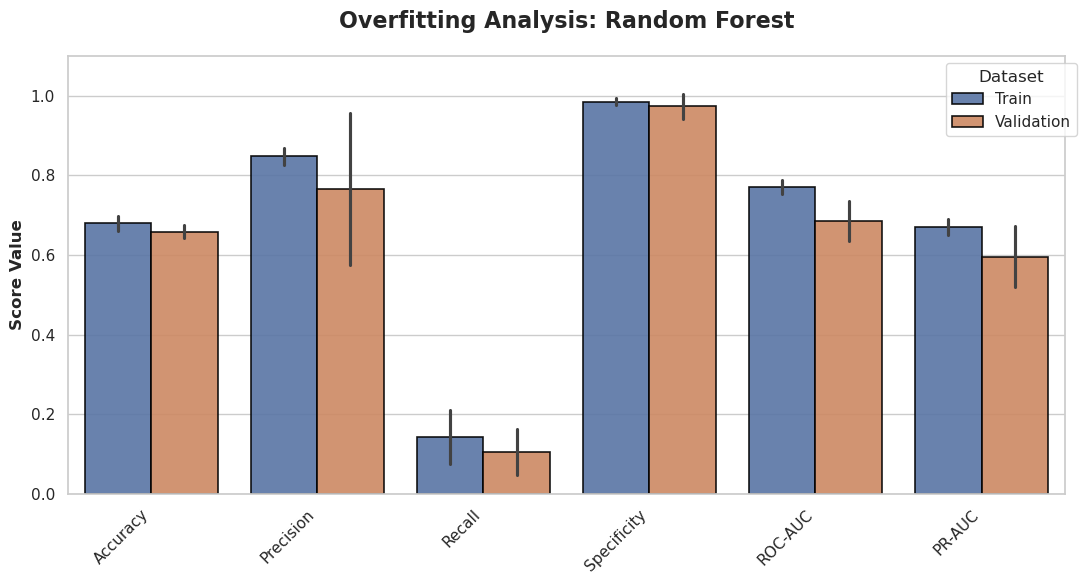

In [25]:
plot_overfitting_bars(df_cv_results=cv_results_RF, 
                    title="Random Forest", 
                    output_dir=results_path, 
                    identifier="RF")

#### Extra Trees


Define the parameter distributions and set up the pipeline:


In [26]:
# Hyperparameters search space
params_dist_ET = {
    'clf__n_estimators': IntDistribution(20, 300),
    'clf__max_depth': IntDistribution(2, 32),
    'clf__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'clf__min_samples_split': IntDistribution(2, 20),
    'clf__criterion': CategoricalDistribution(['gini', 'entropy']),
    'clf__class_weight': CategoricalDistribution([None, 'balanced', 'balanced_subsample'])
}

# Get the preprocessor (using the same as RF)
preprocessor_ET = get_trees_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_ET = Pipeline(steps=[
    ('preprocessor', preprocessor_ET),
    ('clf', ExtraTreesClassifier(random_state=seed))
])


Train and optimize the model:


In [27]:
(
optimized_ET, 
cv_results_ET,
fpr_ET, tpr_ET,
precs_ET, recs_ET,
study_ET
) = optimize_model_optuna_search(
    pipeline=pipe_ET, 
    param_distributions=params_dist_ET, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    seed=seed
    )


Starting hyperparameter optimization...
Evaluating on the training set...
Evaluating on the test set...


Check the optimization history:


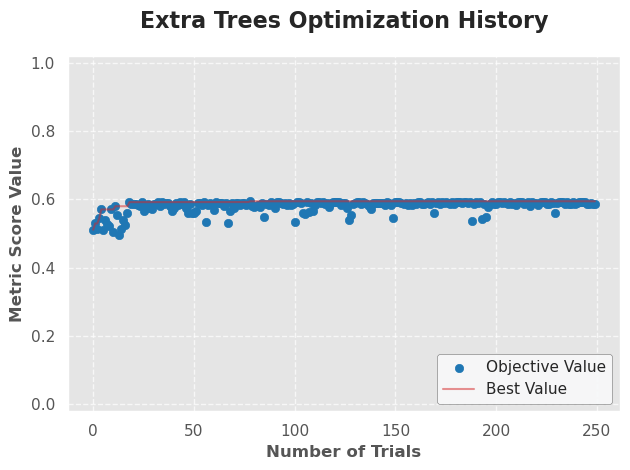

In [28]:
# Update the model's name in the study's user attributes
study_ET.set_user_attr("model_name", "Extra Trees")

# Plot the optimization history progress
plot_optimization_history(study=study_ET, output_dir=results_path, identifier="ET")


Save the optimized model and check the hyperparameters:


In [29]:
save_model(fitted_pipeline=optimized_ET, output_dir=results_path, identifier="ET")


,Hyperparameter,Optimal Value
1,bootstrap,False
2,ccp_alpha,0.0
3,criterion,entropy
4,max_depth,5
5,max_features,log2
6,min_impurity_decrease,0.0
7,min_samples_leaf,1
8,min_samples_split,17
9,min_weight_fraction_leaf,0.0
10,n_estimators,246


Check the overfitting:


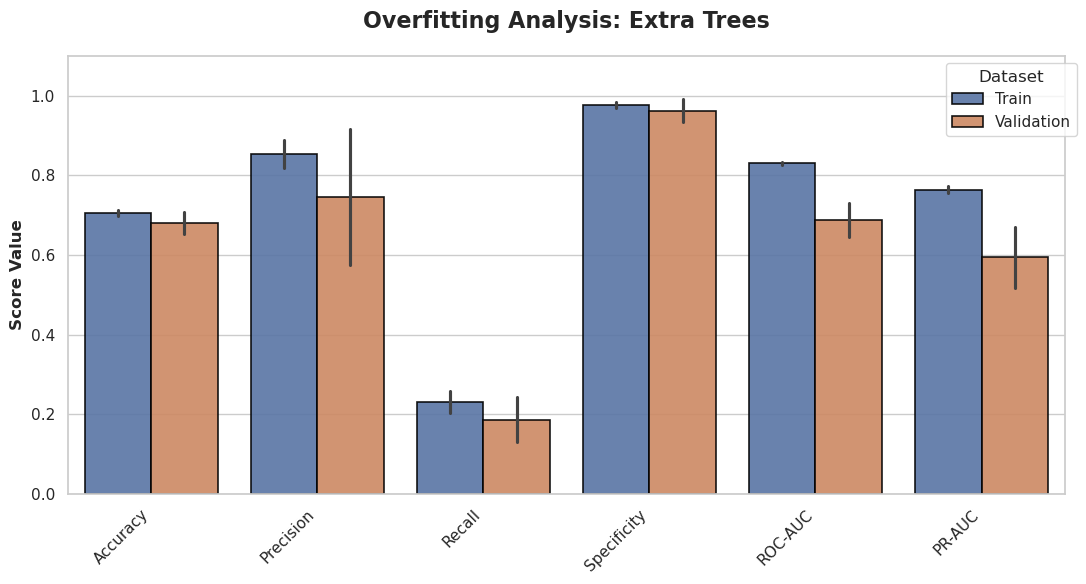

In [30]:
plot_overfitting_bars(df_cv_results=cv_results_ET, 
                    title="Extra Trees", 
                    output_dir=results_path, 
                    identifier="ET")


#### Extreme Gradient Boosting

Define the parameter distributions and set up the pipeline:

In [31]:
# Hyperparameters search space
params_dist_XGB = {
    'clf__n_estimators': IntDistribution(20, 300),
    'clf__max_depth': IntDistribution(3, 10),
    'clf__learning_rate': FloatDistribution(0.01, 0.3),
    
    'clf__subsample': FloatDistribution(0.4, 0.6),
    'clf__colsample_bytree': FloatDistribution(0.4, 0.6),
    
    # Regularization parameters:
    'clf__reg_alpha': FloatDistribution(0, 10),
    'clf__reg_lambda': FloatDistribution(1, 10)
}

# Get the preprocessor
preprocessor_XGB = get_boost_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_XGB = Pipeline(steps=[
    ('preprocessor', preprocessor_XGB),
    ('clf', XGBClassifier(random_state=seed,
                        n_jobs=-1,
                        scale_pos_weight=ratio, 
                        eval_metric='logloss'))
])

Train and optimize the model:

In [32]:
(
optimized_XGB, 
cv_results_XGB,
fpr_XGB, tpr_XGB,
precs_XGB, recs_XGB,
study_XGB
) = optimize_model_optuna_search(
    pipeline=pipe_XGB, 
    param_distributions=params_dist_XGB, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    seed=seed
    )

Starting hyperparameter optimization...
Evaluating on the training set...
Evaluating on the test set...


Check the optimization history:

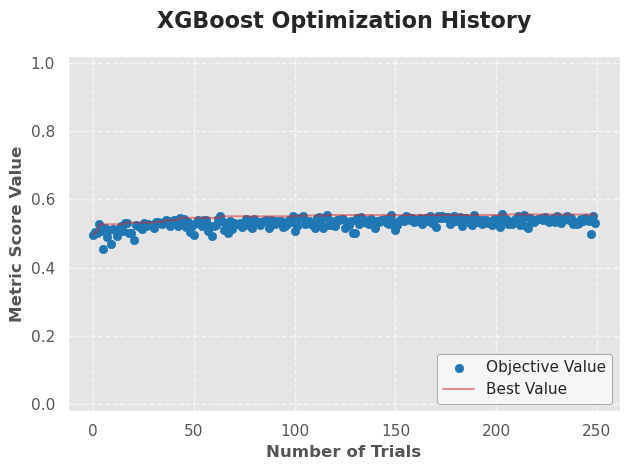

In [33]:
# Update the model's name in the study's user attributes
study_XGB.set_user_attr("model_name", "XGBoost")

# Plot the optimization history progress
plot_optimization_history(study=study_XGB, output_dir=results_path, identifier="XGB")

Save the optimized model and check the hyperparameters:

In [34]:
save_model(fitted_pipeline=optimized_XGB, output_dir=results_path, identifier="XGB")

,Hyperparameter,Optimal Value
1,objective,binary:logistic
2,colsample_bytree,0.586785
3,enable_categorical,False
4,eval_metric,logloss
5,learning_rate,0.14936
6,max_depth,9
7,n_estimators,60
8,n_jobs,-1
9,random_state,7214
10,reg_alpha,9.326248


Check the overfitting:

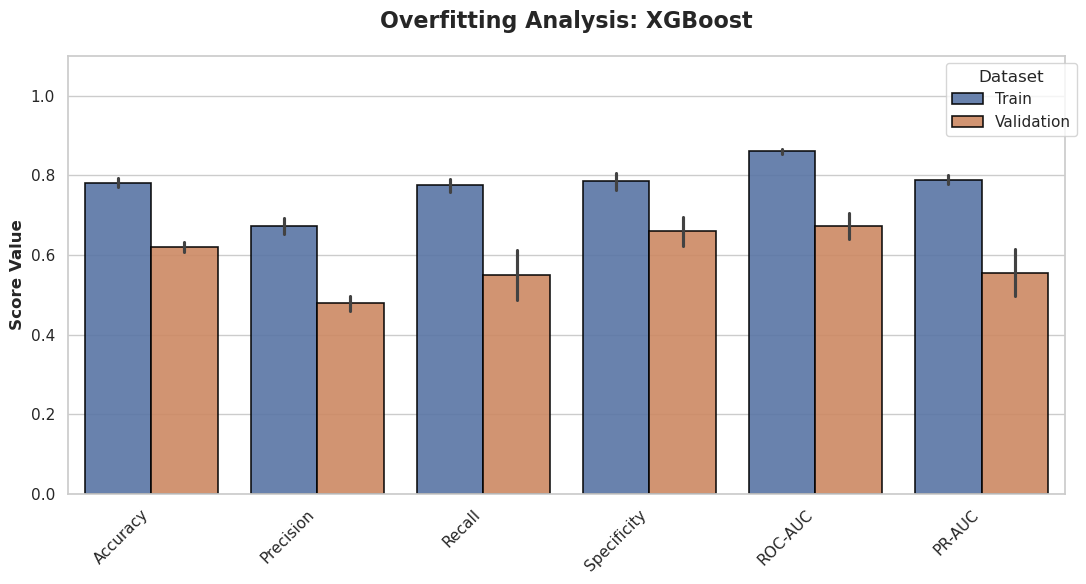

In [35]:
plot_overfitting_bars(df_cv_results=cv_results_XGB, 
                    title="XGBoost", 
                    output_dir=results_path, 
                    identifier="XGB")

#### Categorical Boosting


Define the parameter distributions and set up the pipeline:


In [36]:
# Hyperparameters search space
params_dist_CB = {
    'clf__iterations': IntDistribution(100, 1000),
    'clf__depth': IntDistribution(4, 10),
    'clf__learning_rate': FloatDistribution(0.01, 0.3, log=True),
    'clf__l2_leaf_reg': FloatDistribution(1, 10),
    'clf__border_count': IntDistribution(32, 255),
}

# Get the preprocessor
preprocessor_CB = get_boost_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_CB = Pipeline(steps=[
    ('preprocessor', preprocessor_CB),
    ('clf', CatBoostClassifier(random_state=seed,
                            thread_count=-1, 
                            verbose=False,
                            allow_writing_files=False,
                            scale_pos_weight=ratio))
])


Train and optimize the model:


In [37]:
(
optimized_CB, 
cv_results_CB,
fpr_CB, tpr_CB,
precs_CB, recs_CB,
study_CB
) = optimize_model_optuna_search(
    pipeline=pipe_CB, 
    param_distributions=params_dist_CB, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_startup_trials=40,
    n_iter=100,
    seed=seed
    )


Starting hyperparameter optimization...
Evaluating on the training set...
Evaluating on the test set...


Check the optimization history:


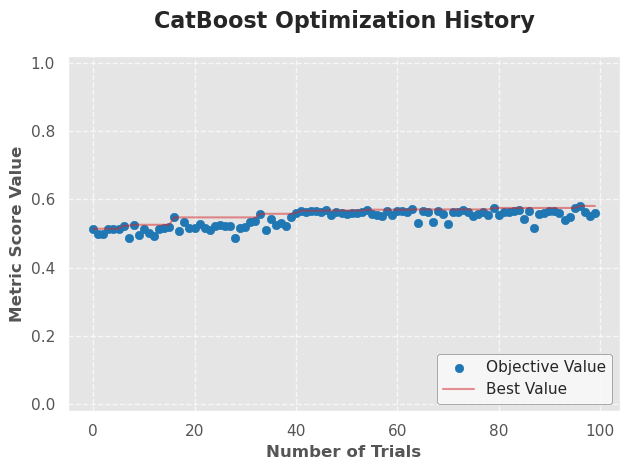

In [38]:
# Update the model's name in the study's user attributes
study_CB.set_user_attr("model_name", "CatBoost")

# Plot the optimization history progress
plot_optimization_history(study=study_CB, output_dir=results_path, identifier="CB")


Save the optimized model and check the hyperparameters:


In [39]:
save_model(fitted_pipeline=optimized_CB, output_dir=results_path, identifier="CB")


,Hyperparameter,Optimal Value
1,verbose,False
2,allow_writing_files,False
3,random_state,7214
4,scale_pos_weight,1.755981
5,iterations,288
6,depth,4
7,learning_rate,0.026881
8,l2_leaf_reg,9.344756
9,border_count,142


Check the overfitting:


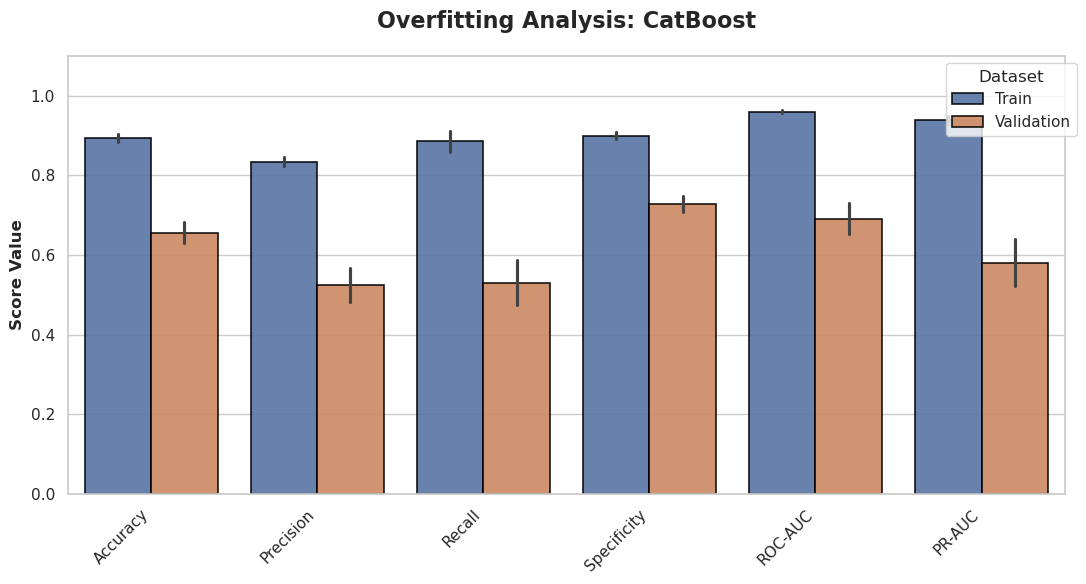

In [40]:
plot_overfitting_bars(df_cv_results=cv_results_CB, 
                    title="CatBoost", 
                    output_dir=results_path, 
                    identifier="CB")


#### Multi-Layer Perceptron

Define the parameter distributions and set up the pipeline:

In [41]:
from sklearn.neural_network import MLPClassifier

# Hyperparameters search space
params_dist_MLP = {
    'clf__hidden_layer_sizes': CategoricalDistribution([(50,), (100,), (100, 50), (100, 100), (200, 100)]),
    'clf__alpha': FloatDistribution(1e-5, 1e-1, log=True),
    'clf__learning_rate_init': FloatDistribution(0.001, 0.01, log=True),
    'clf__batch_size': CategoricalDistribution([16, 32, 64]),
    'clf__activation': CategoricalDistribution(['relu', 'tanh']),
    'clf__solver': CategoricalDistribution(['adam', 'sgd'])
}

# Get the preprocessor
preprocessor_MLP = get_full_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_MLP = Pipeline(steps=[
    ('preprocessor', preprocessor_MLP),
    ('clf', MLPClassifier(random_state=seed, max_iter=1000, early_stopping=True, validation_fraction=0.1))
])


/opt/conda/envs/tfm/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
/opt/conda/envs/tfm/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
/opt/conda/envs/tfm/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  warnings.warn(message)
/opt/conda/envs/tfm/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float an

Train and optimize the model:

In [42]:
(
optimized_MLP, 
cv_results_MLP,
fpr_MLP, tpr_MLP,
precs_MLP, recs_MLP,
study_MLP
) = optimize_model_optuna_search(
    pipeline=pipe_MLP, 
    param_distributions=params_dist_MLP, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_startup_trials=30,
    n_iter=100,
    seed=seed
    )


Starting hyperparameter optimization...
Evaluating on the training set...
Evaluating on the test set...


Check the optimization history:

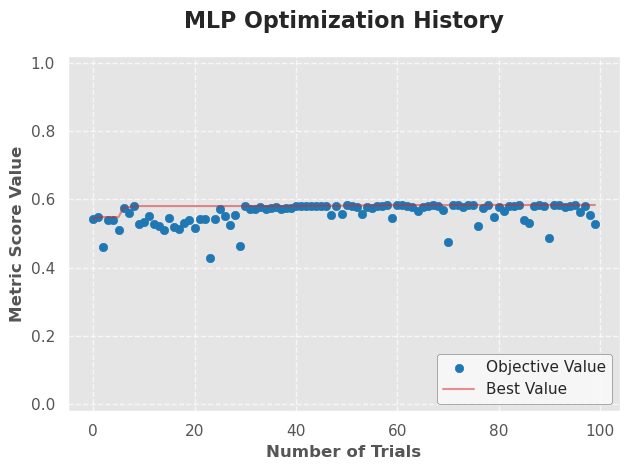

In [43]:
# Update the model's name in the study's user attributes
study_MLP.set_user_attr("model_name", "MLP")

# Plot the optimization history progress
plot_optimization_history(study=study_MLP, output_dir=results_path, identifier="MLP")


Save the optimized model and check the hyperparameters:

In [44]:
save_model(fitted_pipeline=optimized_MLP, output_dir=results_path, identifier="MLP")


,Hyperparameter,Optimal Value
1,activation,tanh
2,alpha,0.002586
3,batch_size,64
4,beta_1,0.9
5,beta_2,0.999
6,early_stopping,True
7,epsilon,0.0
8,hidden_layer_sizes,"(100, 50)"
9,learning_rate,constant
10,learning_rate_init,0.002931


Check the overfitting:

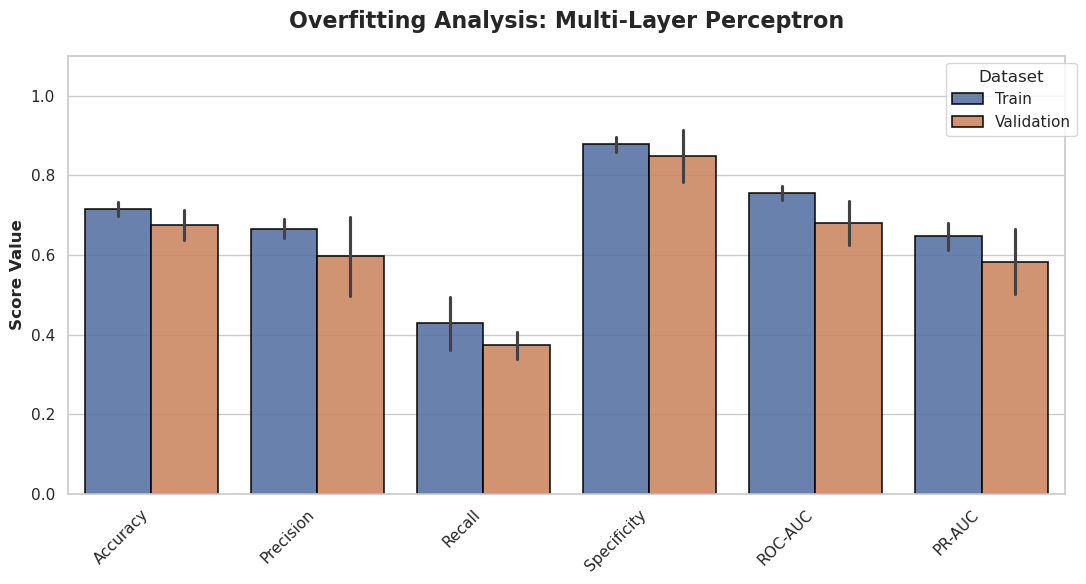

In [45]:
plot_overfitting_bars(df_cv_results=cv_results_MLP, 
                    title="Multi-Layer Perceptron", 
                    output_dir=results_path, 
                    identifier="MLP")


## Save results

In [46]:
models = ["Elastic Net", "SVM", "Random Forest", "Extra Trees", "XGBoost", "CatBoost", "MLP"]

models_dict = {
    "Elastic Net": cv_results_EN,
    "SVM": cv_results_SVM,
    "Random Forest": cv_results_RF,
    "Extra Trees": cv_results_ET,
    "XGBoost": cv_results_XGB,
    "CatBoost": cv_results_CB,
    "MLP": cv_results_MLP
}


### Main metrics

In [47]:
results = save_metrics_results(models_dict=models_dict, output_dir=results_path)

results.head()

,Model,Metric,Dataset,Score
0,Elastic Net,Accuracy,Train,0.697826
1,Elastic Net,Accuracy,Validation,0.637931
2,Elastic Net,Accuracy,Train,0.694143
3,Elastic Net,Accuracy,Validation,0.634783
4,Elastic Net,Accuracy,Train,0.689805


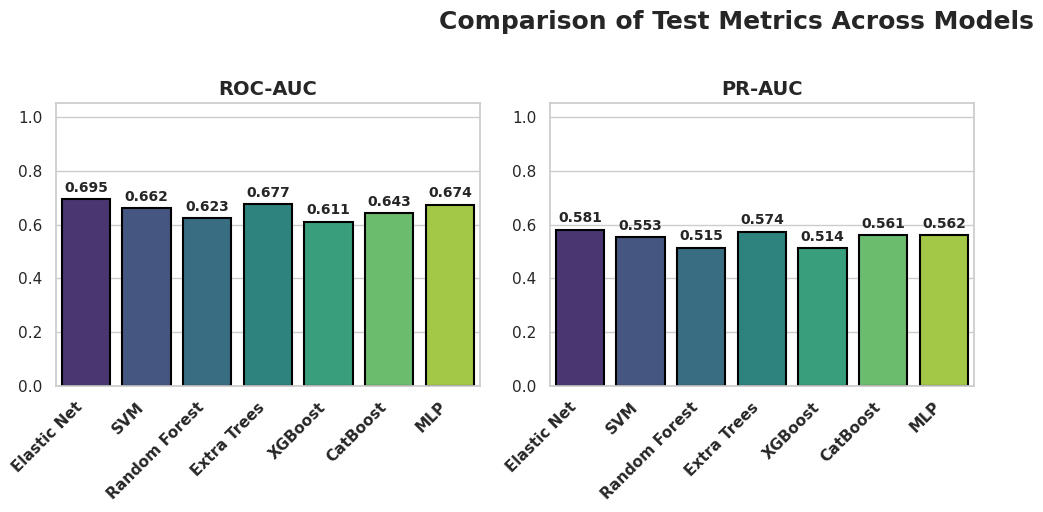

In [48]:
plot_metrics_bars(results, 
                metrics=['ROC-AUC', 'PR-AUC'],
                output_dir=results_path)

### ROC and PR curves

Join the metrics into a csv file:

In [49]:
# Save the false/true positive rates values into a csv
fpr = [fpr_EN, fpr_SVM, fpr_RF, fpr_ET, fpr_XGB, fpr_CB, fpr_MLP]
tpr = [tpr_EN, tpr_SVM, tpr_RF, tpr_ET, tpr_XGB, tpr_CB, tpr_MLP]

roc_results = save_curves_results(models, fpr, tpr, curve_type='roc', 
                                output_dir=results_path)

# Save the precision and recall values for the PR curves into a csv
precs = [precs_EN, precs_SVM, precs_RF, precs_ET, precs_XGB, precs_CB, precs_MLP]
recs = [recs_EN, recs_SVM, recs_RF, recs_ET, recs_XGB, recs_CB, recs_MLP]

pr_results = save_curves_results(models, recs, precs, curve_type='pr', 
                                output_dir=results_path)


Plot ROC curves:

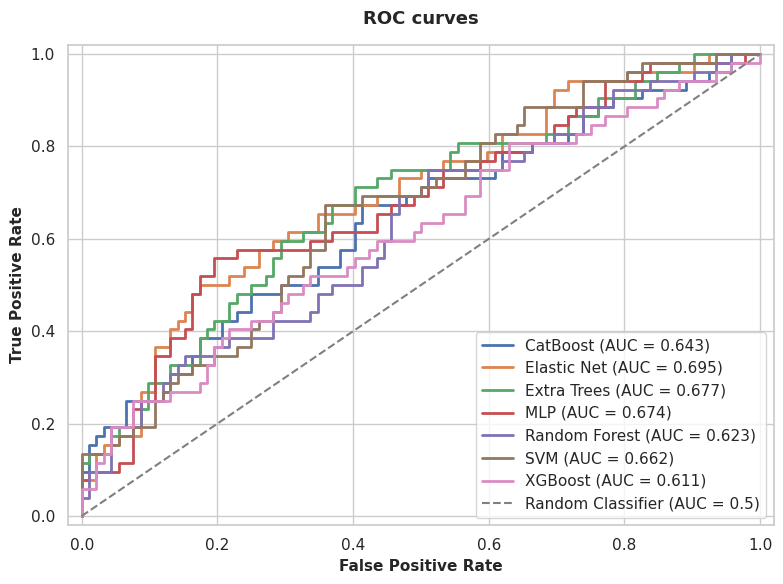

In [50]:
plot_model_curves(roc_results, 
                x_col='False Positive Rate', y_col='True Positive Rate', 
                curve_type='roc', title="ROC curves",
                output_dir=results_path)

Plot PR curves:

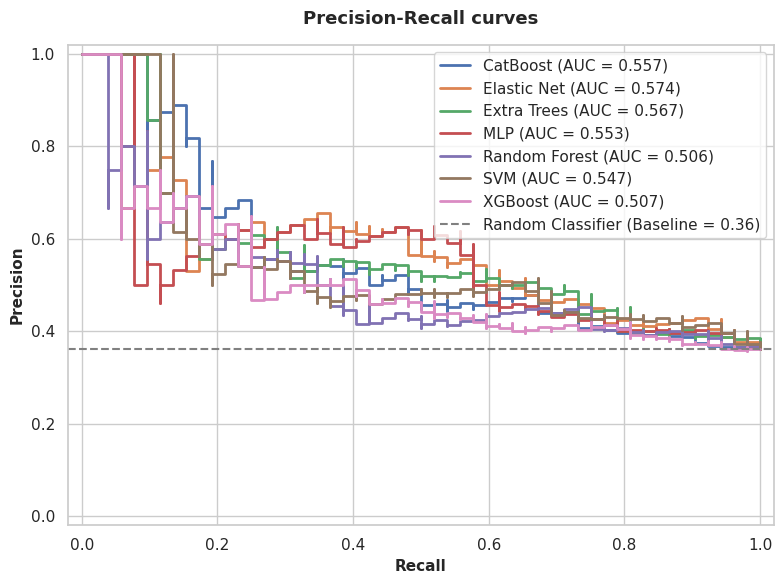

In [51]:
# Use the actual prevalence for the random classifier baseline
test_prevalence = y_test.astype(float).mean()

plot_model_curves(pr_results, 
                x_col='Recall', y_col='Precision', 
                curve_type='pr', title="Precision-Recall curves",
                prevalence=test_prevalence,
                output_dir=results_path)
